In [15]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict

import os
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

from collections import deque
import numpy as np


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import TwoSlopeNorm, Normalize


def get_bout_id(file_path: Path):
    """
    Extract bout id from filenames like:
        bout_00900_metrics.npz
    """
    for part in file_path.stem.split("_"):
        if part.isdigit():
            return int(part)
    return None


def load_bouts_from_run(
    run_folder: Path,
    min_bout: int | None = None,
    max_bout: int | None = None,
    bout_glob: str = "bout_*_metrics.npz",
):
    """
    Load selected bout npz files from one agent/run folder.
    """
    bouts = []

    for file_path in sorted(run_folder.glob(bout_glob)):
        bout_id = get_bout_id(file_path)

        if bout_id is None:
            continue
        if min_bout is not None and bout_id < min_bout:
            continue
        if max_bout is not None and bout_id > max_bout:
            continue

        loaded = np.load(file_path, allow_pickle=True)
        bout = {k: loaded[k] for k in loaded.files}
        bout["bout_id"] = bout_id
        bouts.append(bout)

    bouts = sorted(bouts, key=lambda b: b["bout_id"])
    return bouts

In [ ]:
def compute_node_mean_z(
    bouts,
    z_key: str = "z_q",
    z_dim: int = 0,
    num_nodes: int = 127,
    use_mask: bool = True,
):
    """
    Compute mean z-unit activity per maze node.

    Alignment:
        z[t] is assigned to obs_full[t + 1]

    Returns
    -------
    node_values : np.ndarray, shape (num_nodes,)
        Mean z value per node. NaN for unvisited nodes.
    node_counts : np.ndarray, shape (num_nodes,)
        Number of samples contributing to each node.
    """

    sums = np.zeros(num_nodes, dtype=float)
    counts = np.zeros(num_nodes, dtype=float)

    for b in bouts:
        if "obs_full" not in b or z_key not in b:
            continue

        obs = np.asarray(b["obs_full"]).astype(int).reshape(-1)
        z = np.asarray(b[z_key], dtype=float)

        if z.ndim != 2:
            continue
        if z_dim < 0 or z_dim >= z.shape[1]:
            raise ValueError(f"z_dim={z_dim} is invalid for {z_key} with shape {z.shape}")

        if use_mask and "mask" in b:
            mask = np.asarray(b["mask"]).astype(bool).reshape(-1)
        else:
            mask = np.ones(z.shape[0], dtype=bool)

        L = min(z.shape[0], mask.shape[0], max(0, len(obs) - 1))
        if L <= 0:
            continue

        nodes = obs[1:1 + L]
        vals = z[:L, z_dim]

        good = (
            mask[:L]
            & np.isfinite(vals)
            & (nodes >= 0)
            & (nodes < num_nodes)
        )

        for n, v in zip(nodes[good], vals[good]):
            sums[int(n)] += float(v)
            counts[int(n)] += 1.0

    node_values = np.full(num_nodes, np.nan, dtype=float)
    valid = counts > 0
    node_values[valid] = sums[valid] / counts[valid]

    return node_values, counts

In [5]:

def compute_node_points_from_contents(content_path, min_points_per_node=1):
   
    node_points = {}
    with open(content_path, "rb") as f:
        content = pickle.load(f)
    num_bouts = len(content.ke)
    for bout_idx in range(num_bouts):
        ke_bout = np.asarray(content.ke[bout_idx])  # (T,2)
        no_bout = np.asarray(content.no[bout_idx])  # (K,2)
        if ke_bout.size == 0 or no_bout.size == 0:
            continue
        T = ke_bout.shape[0]
        node_per_frame = np.full(T, np.nan)
        for i, (node_id, start_frame) in enumerate(no_bout):
            start = int(start_frame)
            end = int(no_bout[i + 1, 1]) if i + 1 < len(no_bout) else T
            start = max(0, min(start, T))
            end   = max(start, min(end, T))
            node_per_frame[start:end] = int(node_id)
        valid = ~np.isnan(node_per_frame)
        if not np.any(valid):
            continue
        xs = ke_bout[valid, 0]
        ys = ke_bout[valid, 1]
        ns = node_per_frame[valid].astype(int)
        for x, y, n in zip(xs, ys, ns):
            d = node_points.setdefault(int(n), {"x": [], "y": [], "count": 0})
            d["x"].append(float(x))
            d["y"].append(float(y))
            d["count"] += 1

    node_points = {n: d for n, d in node_points.items() if d["count"] >= min_points_per_node}
    return node_points



node_points = compute_node_points_from_contents(Path(f"../outdata/A1a-tf"))

In [6]:
def plot_node_values_on_maze(
    node_points: dict,
    node_values: np.ndarray,
    title: str = "",
    cmap: str = "coolwarm",
    point_size: int = 6,
    alpha: float = 0.9,
    max_points_per_node: int = 150,
    center_zero: bool = True,
    color_bounds: tuple[float, float] | None = None,
    colorbar_label: str = "value",
    flip_y: bool = True,
    ax=None,
):
    """
    Plot scalar node values on physical maze coordinates.

    Parameters
    ----------
    center_zero:
        If True, use symmetric color scale around 0.
        Good for latent z units.
    """

    all_x, all_y, all_c = [], [], []

    finite_y_for_flip = []
    if flip_y:
        for pts in node_points.values():
            ys = np.asarray(pts["y"], dtype=float)
            finite_y_for_flip.extend(ys[np.isfinite(ys)])
        H = np.max(finite_y_for_flip) if len(finite_y_for_flip) else 0.0
    else:
        H = 0.0

    rng = np.random.default_rng(0)

    for node_id, pts in node_points.items():
        if node_id >= len(node_values):
            continue

        val = node_values[node_id]
        if not np.isfinite(val):
            continue

        xs = np.asarray(pts["x"], dtype=float)
        ys = np.asarray(pts["y"], dtype=float)

        good = np.isfinite(xs) & np.isfinite(ys)
        xs = xs[good]
        ys = ys[good]

        if len(xs) == 0:
            continue

        if flip_y:
            ys = H - ys

        if len(xs) > max_points_per_node:
            idx = rng.choice(len(xs), max_points_per_node, replace=False)
            xs = xs[idx]
            ys = ys[idx]

        all_x.append(xs)
        all_y.append(ys)
        all_c.append(np.full(xs.shape, val, dtype=float))

    if len(all_x) == 0:
        print("Nothing to plot.")
        return None, None

    all_x = np.concatenate(all_x)
    all_y = np.concatenate(all_y)
    all_c = np.concatenate(all_c)

    if color_bounds is not None:
        vmin, vmax = color_bounds
    else:
        if center_zero:
            abs_max = np.nanmax(np.abs(all_c))
            vmin, vmax = -abs_max, abs_max
        else:
            vmin, vmax = np.nanmin(all_c), np.nanmax(all_c)

    if center_zero:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    sc = ax.scatter(
        all_x,
        all_y,
        c=all_c,
        s=point_size,
        cmap=cmap,
        norm=norm,
        alpha=alpha,
        linewidths=0,
        rasterized=True,
    )

    ax.set_aspect("equal", "box")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    cbar = fig.colorbar(sc, ax=ax, shrink=0.85)
    cbar.set_label(colorbar_label)

    return fig, ax

In [7]:
def plot_z_units_on_maze(
    run_folder: Path,
    node_points: dict,
    z_key: str = "z_q",
    z_dims: list[int] | None = None,
    min_bout: int = 900,
    max_bout: int = 1000,
    bout_glob: str = "bout_*_metrics.npz",
    num_nodes: int = 127,
    cmap: str = "coolwarm",
    center_zero: bool = True,
    shared_color_scale: bool = False,
    point_size: int = 6,
    alpha: float = 0.9,
    max_points_per_node: int = 150,
    ncols: int = 4,
    save_path: str | None = None,
):
    """
    Plot z-unit node maps for one agent/run.

    Parameters
    ----------
    shared_color_scale:
        If True, all z dims share one symmetric color scale.
        If False, each z dim gets its own color scale.
    """

    bouts = load_bouts_from_run(
        run_folder=run_folder,
        min_bout=min_bout,
        max_bout=max_bout,
        bout_glob=bout_glob,
    )

    if len(bouts) == 0:
        raise ValueError(f"No bouts found in {run_folder} for range {min_bout}-{max_bout}")

    # infer z dimensionality
    D = None
    for b in bouts:
        if z_key in b:
            z = np.asarray(b[z_key])
            if z.ndim == 2:
                D = z.shape[1]
                break

    if D is None:
        raise ValueError(f"Could not find valid {z_key} in selected bouts.")

    if z_dims is None:
        z_dims = list(range(D))
    else:
        z_dims = list(z_dims)

    node_values_by_dim = {}
    node_counts_by_dim = {}

    for d in z_dims:
        vals, counts = compute_node_mean_z(
            bouts=bouts,
            z_key=z_key,
            z_dim=d,
            num_nodes=num_nodes,
        )
        node_values_by_dim[d] = vals
        node_counts_by_dim[d] = counts

    if shared_color_scale:
        all_vals = np.concatenate([
            node_values_by_dim[d][np.isfinite(node_values_by_dim[d])]
            for d in z_dims
        ])

        if center_zero:
            abs_max = np.nanmax(np.abs(all_vals))
            color_bounds = (-abs_max, abs_max)
        else:
            color_bounds = (np.nanmin(all_vals), np.nanmax(all_vals))
    else:
        color_bounds = None

    nrows = int(np.ceil(len(z_dims) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.2 * ncols, 4.0 * nrows),
        squeeze=False,
    )
    axes = axes.reshape(-1)

    for ax, d in zip(axes, z_dims):
        plot_node_values_on_maze(
            node_points=node_points,
            node_values=node_values_by_dim[d],
            title=f"{z_key}[{d}]",
            cmap=cmap,
            point_size=point_size,
            alpha=alpha,
            max_points_per_node=max_points_per_node,
            center_zero=center_zero,
            color_bounds=color_bounds,
            colorbar_label=f"mean {z_key}[{d}]",
            flip_y=True,
            ax=ax,
        )

    for ax in axes[len(z_dims):]:
        ax.set_axis_off()

    fig.suptitle(
        f"{z_key} node maps | bouts {min_bout}–{max_bout}",
        y=1.01,
    )

    fig.tight_layout()

    if save_path is not None:
        suffix = Path(save_path).suffix.replace(".", "")
        fig.savefig(save_path, format=suffix, bbox_inches="tight", dpi=600)

    plt.show()

    return {
        "fig": fig,
        "axes": axes,
        "node_values_by_dim": node_values_by_dim,
        "node_counts_by_dim": node_counts_by_dim,
        "bouts": bouts,
    }

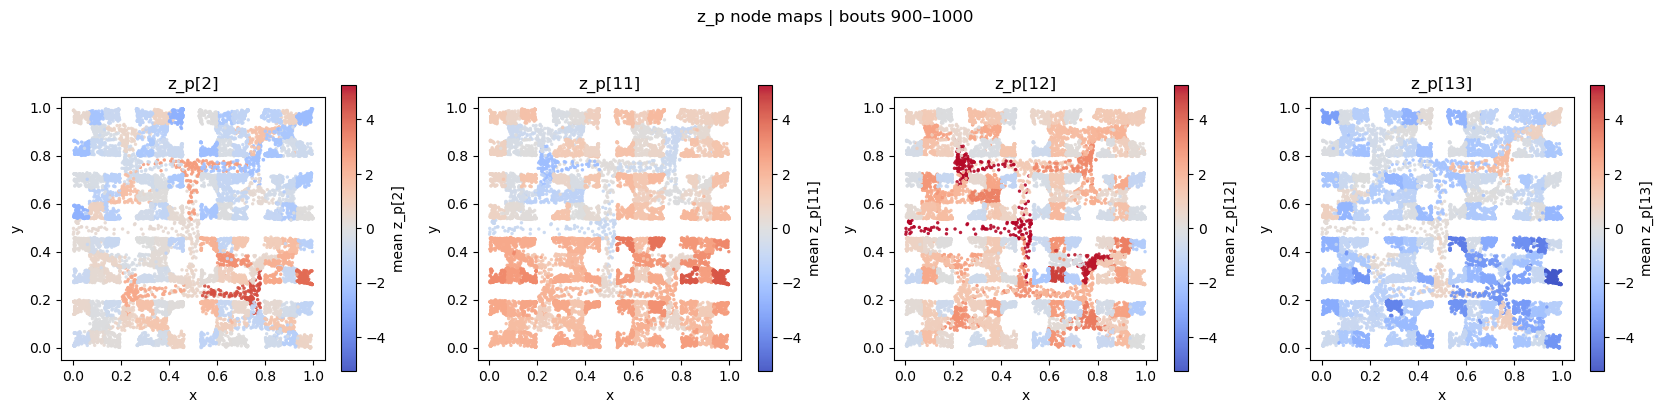

In [64]:
window_size = 20
rew_p = 0.05
seed = 11

base_runs_folder = Path(
    f"../REWARD_DRIVEN_1000/REWARD_DRIVEN_1000_runs_slurm_{window_size}_window_agent_rew_p_{rew_p}"
)

run_folder = base_runs_folder / str(seed)

result = plot_z_units_on_maze(
    run_folder=run_folder,
    node_points=node_points,
    z_key="z_p",
    z_dims=[2,11,12,13],   # or [0, 1, 2, 3]
    # z_dims=range(16),
    min_bout=900,
    max_bout=1000,
    bout_glob="bout_*_metrics.npz",
    cmap="coolwarm",
    center_zero=True,
    shared_color_scale=True,
    point_size=6,
    alpha=0.9,
    max_points_per_node=150,
    ncols=4,
    save_path=f"figs/z_maps_rewp_{rew_p}_seed_{seed}_bouts_900_1000.svg",
)

# path heatmaps

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def get_bout_id(file_path):
    """
    Extract bout id from filenames like:
        bout_00950_metrics.npz
    """
    for part in file_path.stem.split("_"):
        if part.isdigit():
            return int(part)
    return None


def load_bouts_from_run(
    run_folder,
    min_bout=None,
    max_bout=None,
    bout_glob="bout_*_metrics.npz",
):
    """
    Load selected bout .npz files from one run folder.
    """
    run_folder = Path(run_folder)
    bouts = []

    for file_path in sorted(run_folder.glob(bout_glob)):
        bout_id = get_bout_id(file_path)

        if bout_id is None:
            continue
        if min_bout is not None and bout_id < min_bout:
            continue
        if max_bout is not None and bout_id > max_bout:
            continue

        loaded = np.load(file_path, allow_pickle=True)
        bout = {k: loaded[k] for k in loaded.files}
        bout["bout_id"] = bout_id
        bouts.append(bout)

    return sorted(bouts, key=lambda b: b["bout_id"])

In [ ]:
# ============================================================
# Compute mean h activity on selected path transitions
# ============================================================

def compute_mean_h_on_path_transitions(
    bouts,
    path_nodes,
    h_key="h_list",
    abs_activity=True,
    exclude_first_n=0,
    use_mask=True,
):
    """
    Compute mean h activity for each unit on each transition
    along the given path.

    Example:
        path_nodes = [0, 2, 6, 13, 28, 57, 116]

    transitions are:
        0->2, 2->6, 6->13, 13->28, 28->57, 57->116

    At timestep t we use:
        prev_node = obs_full[t]
        next_node = obs_full[t+1]
        h[t]

    We keep h[t] only if (prev_node, next_node) is one of the path transitions.

    Returns
    -------
    mean_mat : np.ndarray, shape (n_units, n_transitions)
        Mean activity per unit per transition

    counts : np.ndarray, shape (n_units, n_transitions)
        Number of samples contributing to each cell

    transitions : list of tuple
        List like [(0,2), (2,6), ...]
    """

    path_nodes = list(path_nodes)
    if len(path_nodes) < 2:
        raise ValueError("path_nodes must contain at least 2 nodes.")

    transitions = [(path_nodes[i], path_nodes[i + 1]) for i in range(len(path_nodes) - 1)]
    transition_to_col = {tr: i for i, tr in enumerate(transitions)}
    n_transitions = len(transitions)

    # infer number of units
    n_units = None
    for b in bouts:
        if h_key in b:
            h = np.asarray(b[h_key], dtype=float)
            if h.ndim == 2:
                n_units = h.shape[1]
                break

    if n_units is None:
        raise ValueError(f"Could not find valid 2D array for h_key='{h_key}'.")

    sums = np.zeros((n_units, n_transitions), dtype=float)
    counts = np.zeros((n_units, n_transitions), dtype=float)

    for b in bouts:
        if "obs_full" not in b or h_key not in b:
            continue

        obs = np.asarray(b["obs_full"]).astype(int).reshape(-1)
        h = np.asarray(b[h_key], dtype=float)

        if h.ndim != 2 or h.shape[1] != n_units:
            continue

        if use_mask and "mask" in b:
            mask = np.asarray(b["mask"]).astype(bool).reshape(-1)
        else:
            mask = np.ones(h.shape[0], dtype=bool)

        # transition alignment:
        # h[t] is paired with obs[t] -> obs[t+1]
        L = min(h.shape[0], mask.shape[0], max(0, len(obs) - 1))
        if L <= 0:
            continue

        prev_nodes = obs[:L]
        next_nodes = obs[1:1 + L]
        vals = h[:L]

        valid = (
            mask[:L]
            & np.all(np.isfinite(vals), axis=1)
        )

        if exclude_first_n > 0:
            valid &= (np.arange(L) >= exclude_first_n)

        prev_nodes = prev_nodes[valid]
        next_nodes = next_nodes[valid]
        vals = vals[valid]

        if abs_activity:
            vals = np.abs(vals)

        if len(prev_nodes) == 0:
            continue

        for i in range(len(prev_nodes)):
            tr = (int(prev_nodes[i]), int(next_nodes[i]))
            if tr not in transition_to_col:
                continue

            col = transition_to_col[tr]
            sums[:, col] += vals[i]
            counts[:, col] += 1.0

    mean_mat = np.full((n_units, n_transitions), np.nan, dtype=float)
    nonzero = counts > 0
    mean_mat[nonzero] = sums[nonzero] / counts[nonzero]

    return mean_mat, counts, transitions

In [92]:
# ============================================================
# Normalize rows
# ============================================================

def normalize_rows(mean_mat, method="minmax"):
    """
    Normalize each row independently.

    method:
        "none"
        "minmax"
        "zscore"
    """
    mat = mean_mat.copy()

    if method == "none":
        return mat

    elif method == "minmax":
        row_min = np.nanmin(mat, axis=1, keepdims=True)
        row_max = np.nanmax(mat, axis=1, keepdims=True)
        denom = row_max - row_min
        denom[denom == 0] = 1.0
        return (mat - row_min) / denom

    elif method == "zscore":
        row_mean = np.nanmean(mat, axis=1, keepdims=True)
        row_std = np.nanstd(mat, axis=1, keepdims=True)
        row_std[row_std == 0] = 1.0
        return (mat - row_mean) / row_std

    else:
        raise ValueError(f"Unknown normalization method: {method}")

In [93]:
# ============================================================
# Filter low-structure units
# ============================================================

def filter_units_by_variability(mean_mat, counts, variability_threshold=0.0):
    """
    Keep units whose profiles vary enough across path transitions.

    variability = (max - min) / max
    """
    has_any_data = np.any(np.isfinite(mean_mat), axis=1)

    row_max = np.nanmax(mean_mat, axis=1)
    row_min = np.nanmin(mean_mat, axis=1)

    variability = (row_max - row_min) / (row_max + 1e-8)
    keep_mask = has_any_data & (variability > variability_threshold)

    if not np.any(keep_mask):
        raise ValueError(
            f"No units passed variability_threshold={variability_threshold}."
        )

    return mean_mat[keep_mask], counts[keep_mask], keep_mask, variability[keep_mask]

In [170]:
# ============================================================
# Sort by peak transition along the path
# ============================================================

def sort_units_by_peak_transition(mean_mat):
    """
    Sort rows by:
        1) peak transition index ascending
        2) peak value descending within the same transition

    Returns
    -------
    sort_order
    peak_cols_sorted
    peak_vals_sorted
    mean_mat_sorted
    """
    mat_for_sort = mean_mat.copy()
    mat_for_sort[~np.isfinite(mat_for_sort)] = -np.inf

    peak_cols = np.argmax(mat_for_sort, axis=1)
    peak_vals = np.max(mat_for_sort, axis=1)

    sort_order = np.lexsort((-peak_vals, peak_cols))

    return (
        sort_order,
        peak_cols[sort_order],
        peak_vals[sort_order],
        mean_mat[sort_order],
    )

In [95]:
# ============================================================
# Main plotting function
# ============================================================

def plot_h_heatmap_on_path_transitions(
    run_folder,
    path_nodes,
    h_key="h_list",
    min_bout=None,
    max_bout=None,
    bout_glob="bout_*_metrics.npz",
    abs_activity=True,
    exclude_first_n=0,
    variability_threshold=0.0,
    norm_method="minmax",
    cmap="viridis",
    figsize=(10, 8),
    vmin=None,
    vmax=None,
    save_path=None,
):
    """
    Plot h heatmap using only transitions along a specified path.

    Columns:
        path transitions, e.g. 0->2, 2->6, ..., 57->116

    Rows:
        units sorted by where their activity peaks along the path
    """

    bouts = load_bouts_from_run(
        run_folder=run_folder,
        min_bout=min_bout,
        max_bout=max_bout,
        bout_glob=bout_glob,
    )

    if len(bouts) == 0:
        raise ValueError("No bouts found for the selected range.")

    mean_mat, counts, transitions = compute_mean_h_on_path_transitions(
        bouts=bouts,
        path_nodes=path_nodes,
        h_key=h_key,
        abs_activity=abs_activity,
        exclude_first_n=exclude_first_n,
        use_mask=True,
    )

    mean_mat, counts, keep_mask, variability = filter_units_by_variability(
        mean_mat=mean_mat,
        counts=counts,
        variability_threshold=variability_threshold,
    )

    mean_mat = normalize_rows(mean_mat, method=norm_method)

    sort_order, peak_cols_sorted, peak_vals_sorted, mean_mat_sorted = sort_units_by_peak_transition(
        mean_mat
    )
    counts_sorted = counts[sort_order]
    variability_sorted = variability[sort_order]

    if vmin is None:
        vmin = float(np.nanmin(mean_mat_sorted)) if np.any(np.isfinite(mean_mat_sorted)) else 0.0
    if vmax is None:
        vmax = float(np.nanmax(mean_mat_sorted)) if np.any(np.isfinite(mean_mat_sorted)) else 1.0

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        mean_mat_sorted,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        origin="upper",
    )

    # vertical separators between transitions
    for x in range(1, len(transitions)):
        ax.axvline(x - 0.5, linewidth=0.8, color="white", alpha=0.5)

    transition_labels = [f"{a}\u2192{b}" for a, b in transitions]

    ax.set_xticks(np.arange(len(transitions)))
    ax.set_xticklabels(transition_labels, rotation=45, ha="right")

    ax.set_xlabel("Path transition")
    ax.set_ylabel(f"{h_key} unit (sorted by peak transition)")

    title = (
        f"{h_key} heatmap on selected path transitions\n"
        f"path={path_nodes} | "
        f"bouts {min_bout if min_bout is not None else 'start'}–"
        f"{max_bout if max_bout is not None else 'end'} | "
        f"norm={norm_method} | abs_activity={abs_activity}"
    )
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax, shrink=0.95)
    cbar.set_label(f"mean {h_key} activity")

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        fmt = save_path.suffix.replace(".", "") if save_path.suffix else None
        fig.savefig(save_path, format=fmt, bbox_inches="tight", dpi=300)

    plt.show()

    return {
        "bouts": bouts,
        "transitions": transitions,
        "mean_mat": mean_mat,
        "counts": counts,
        "mean_mat_sorted": mean_mat_sorted,
        "counts_sorted": counts_sorted,
        "sort_order": sort_order,
        "peak_cols_sorted": peak_cols_sorted,
        "peak_vals_sorted": peak_vals_sorted,
        "variability_sorted": variability_sorted,
        "keep_mask": keep_mask,
    }

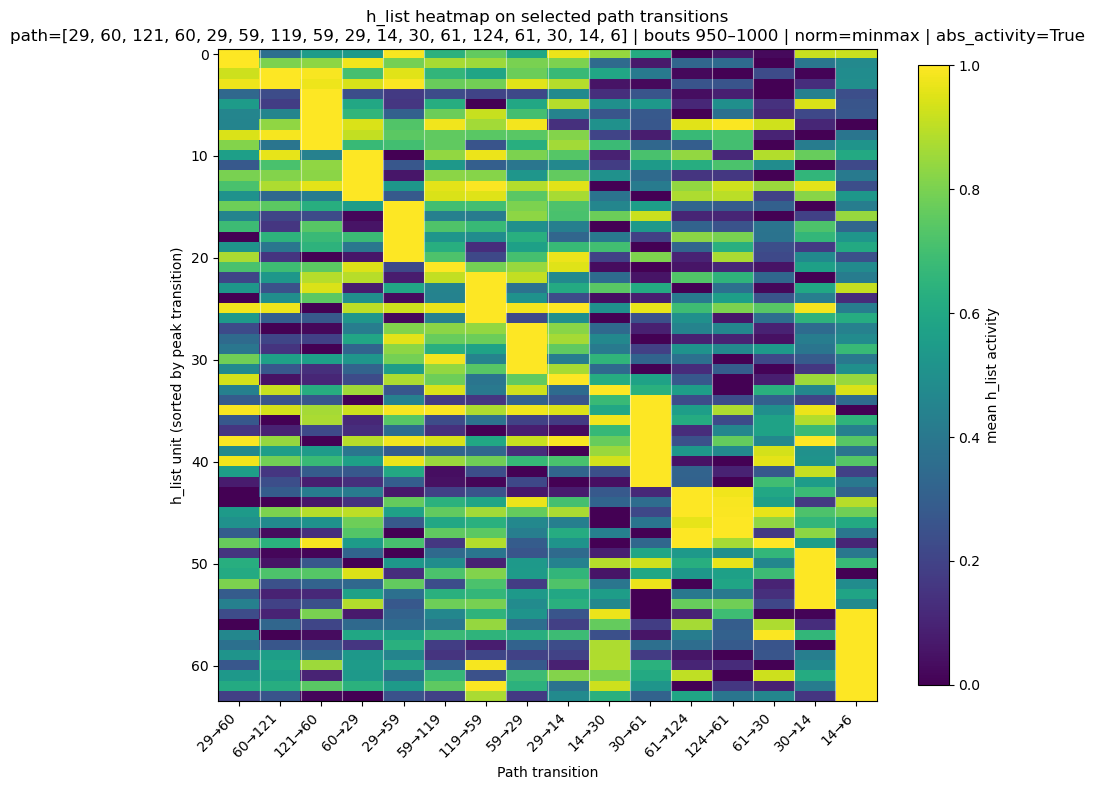

In [171]:

window_size = 20
rew_p = 0.05
seed = 3

base_runs_folder = Path(
    f"../REWARD_DRIVEN_1000/REWARD_DRIVEN_1000_runs_slurm_{window_size}_window_agent_rew_p_{rew_p}"
)

run_folder = base_runs_folder / str(seed)

path_nodes = [ 29, 60, 121, 60, 29, 59, 119, 59, 29, 14, 30, 61, 124, 61, 30, 14, 6]

result = plot_h_heatmap_on_path_transitions(
    run_folder=run_folder,
    path_nodes=path_nodes,
    h_key="h_list",
    min_bout=950,
    max_bout=1000,
    bout_glob="bout_*_metrics.npz",
    abs_activity=True,
    exclude_first_n=0,
    variability_threshold=0.0,
    norm_method="minmax",
    cmap="viridis",
    figsize=(9, 8),
    save_path=f"figs/h_list_path_heatmap_rewp_{rew_p}_seed_{seed}.svg",
)

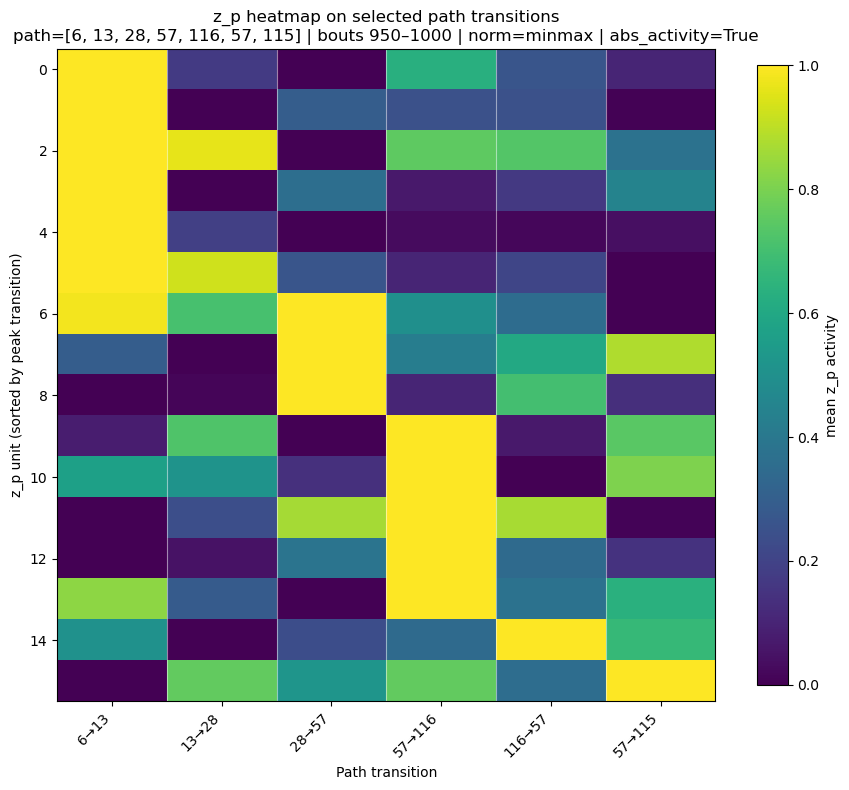

In [169]:
window_size = 20
rew_p = 0.05
seed = 3

base_runs_folder = Path(
    f"../REWARD_DRIVEN_1000/REWARD_DRIVEN_1000_runs_slurm_{window_size}_window_agent_rew_p_{rew_p}"
)

run_folder = base_runs_folder / str(seed)

path_nodes = [ 6, 13, 28, 57, 116, 57, 115]

result = plot_h_heatmap_on_path_transitions(
    run_folder=run_folder,
    path_nodes=path_nodes,
    h_key="z_p",
    min_bout=950,
    max_bout=1000,
    bout_glob="bout_*_metrics.npz",
    abs_activity=True,
    exclude_first_n=0,
    variability_threshold=0.0,
    norm_method="minmax",
    cmap="viridis",
    figsize=(9, 8),
    save_path=f"figs/z_p_path_heatmap_rewp_{rew_p}_seed_{seed}.svg",
)